# Feature Engineering — Deep Dive
**Task 1 Supplement | Adey Innovations Inc.**

Detailed analysis of all engineered features and their relationship to fraud.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_preprocessing import (load_fraud_data, load_ip_country,
    clean_fraud_data, merge_ip_country, engineer_features)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")
RAW = "../data/raw/"
PROC = "../data/processed/"
print("Setup complete")

Setup complete


## 1. Load & Engineer Features

In [2]:
fraud = load_fraud_data(RAW + "Fraud_Data.csv")
ip_df = load_ip_country(RAW + "IpAddress_to_Country.csv")
fraud = clean_fraud_data(fraud)
fraud = merge_ip_country(fraud, ip_df)
fraud = engineer_features(fraud)
print(fraud[["time_since_signup","hour_of_day","day_of_week","user_tx_count","user_tx_velocity"]].describe())

INFO | Loaded Fraud_Data: 151,112 rows, 11 columns.


INFO | Loaded IP-Country map: 138,846 ranges.


INFO | Cleaned Fraud_Data: 151,112 rows remain.


WARNING | 21,966 transactions could not be mapped to a country and are labelled 'Unknown'.


INFO | IP-to-country merge complete.


INFO | Feature engineering complete. New columns: time_since_signup, hour_of_day, day_of_week, user_tx_count, user_tx_velocity.


       time_since_signup    hour_of_day    day_of_week  user_tx_count  \
count      151112.000000  151112.000000  151112.000000       151112.0   
mean         1370.008125      11.521593       3.011819            1.0   
std           868.406422       6.912474       2.006203            0.0   
min             0.000278       0.000000       0.000000            1.0   
25%           607.431528       6.000000       1.000000            1.0   
50%          1368.429306      12.000000       3.000000            1.0   
75%          2123.479028      17.000000       5.000000            1.0   
max          2879.992222      23.000000       6.000000            1.0   

       user_tx_velocity  
count     151112.000000  
mean           1.276359  
std            5.262707  
min            0.008333  
25%            0.011302  
50%            0.017538  
75%            0.039511  
max           24.000000  


## 2. time_since_signup — Key Fraud Signal

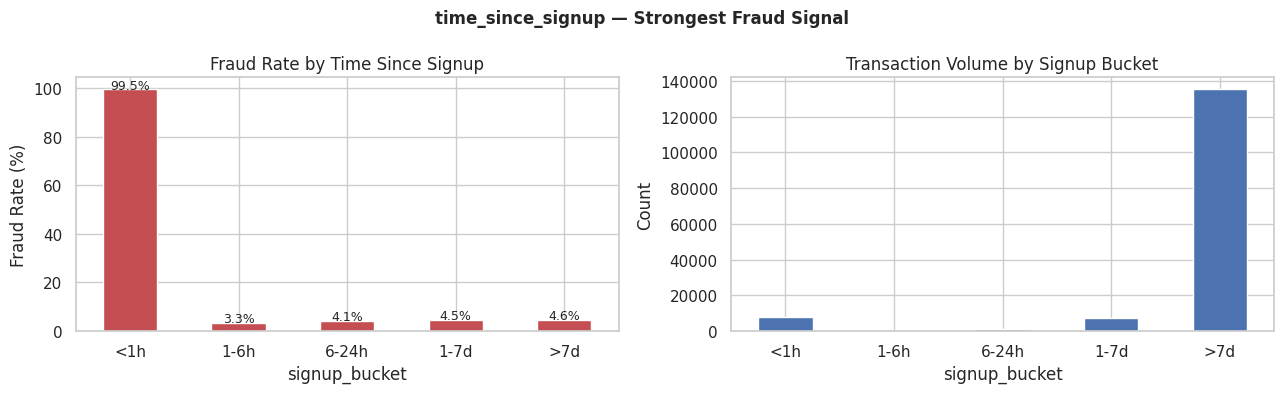

               Fraud Rate %   Count
signup_bucket                      
<1h                   99.52    7641
1-6h                   3.33     240
6-24h                  4.10     877
1-7d                   4.46    7082
>7d                    4.57  135272


In [3]:
fraud["signup_bucket"] = pd.cut(fraud["time_since_signup"],
    bins=[0,1,6,24,168,float("inf")],
    labels=["<1h","1-6h","6-24h","1-7d",">7d"])
fraud_rate = fraud.groupby("signup_bucket", observed=True)["class"].mean() * 100
count = fraud.groupby("signup_bucket", observed=True)["class"].count()
fig, axes = plt.subplots(1,2,figsize=(13,4))
fraud_rate.plot(kind="bar", ax=axes[0], color="#C44E52", edgecolor="white")
axes[0].set_title("Fraud Rate by Time Since Signup")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].tick_params(axis="x", rotation=0)
for i,v in enumerate(fraud_rate.values):
    axes[0].text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=9)
count.plot(kind="bar", ax=axes[1], color="#4C72B0", edgecolor="white")
axes[1].set_title("Transaction Volume by Signup Bucket")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
plt.suptitle("time_since_signup — Strongest Fraud Signal", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(PROC+"fe_signup_analysis.png", bbox_inches="tight")
plt.show()
print(pd.DataFrame({"Fraud Rate %": fraud_rate.round(2), "Count": count}))

## 3. Hour of Day & Day of Week

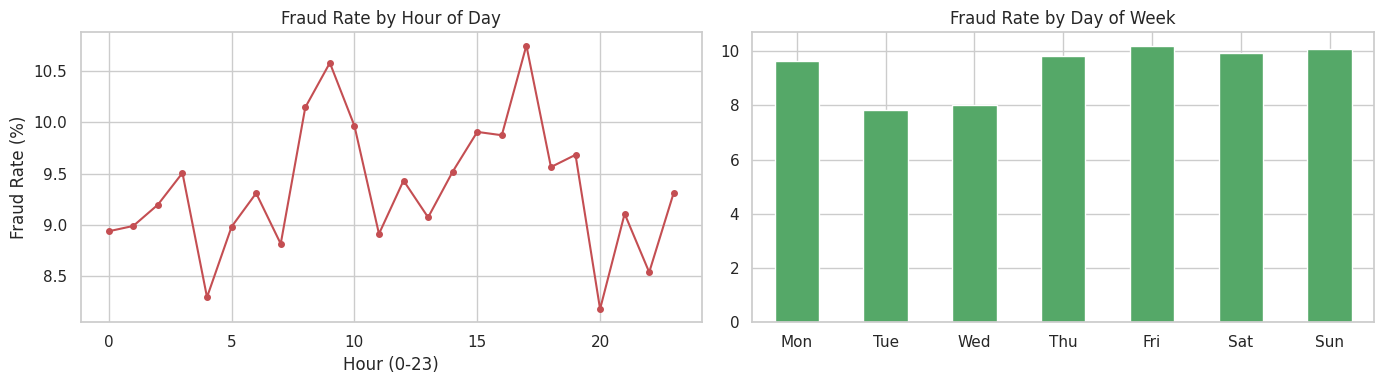

In [4]:
fig, axes = plt.subplots(1,2,figsize=(14,4))
(fraud.groupby("hour_of_day")["class"].mean()*100).plot(
    kind="line", ax=axes[0], color="#C44E52", marker="o", ms=4)
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour (0-23)"); axes[0].set_ylabel("Fraud Rate (%)")
days=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow=(fraud.groupby("day_of_week")["class"].mean()*100)
dow.index=days
dow.plot(kind="bar", ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Fraud Rate by Day of Week")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(PROC+"fe_temporal.png", bbox_inches="tight")
plt.show()

## 4. Transaction Velocity

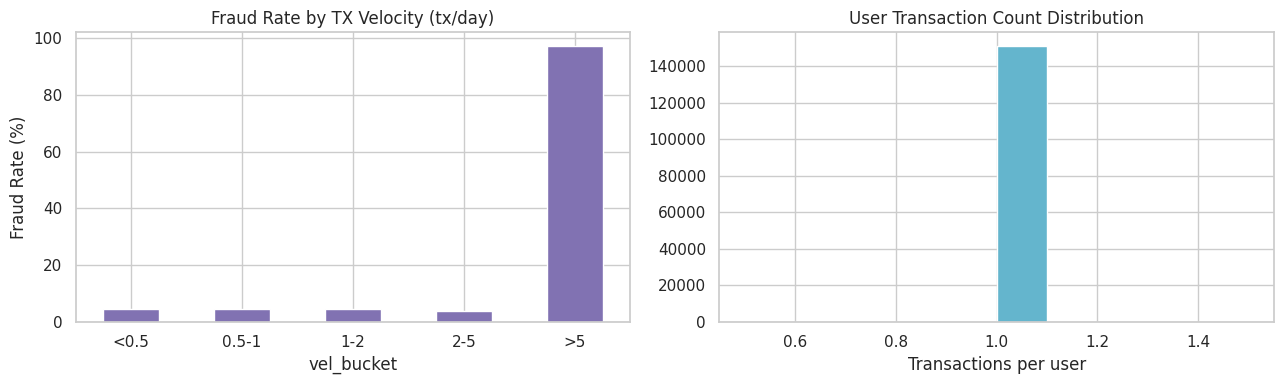

In [5]:
fig, axes = plt.subplots(1,2,figsize=(13,4))
fraud["vel_bucket"] = pd.cut(fraud["user_tx_velocity"],
    bins=[0,0.5,1,2,5,float("inf")],
    labels=["<0.5","0.5-1","1-2","2-5",">5"])
(fraud.groupby("vel_bucket", observed=True)["class"].mean()*100).plot(
    kind="bar", ax=axes[0], color="#8172B2", edgecolor="white")
axes[0].set_title("Fraud Rate by TX Velocity (tx/day)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylabel("Fraud Rate (%)")
fraud["user_tx_count"].clip(0,10).hist(bins=10, ax=axes[1], color="#64B5CD", edgecolor="white")
axes[1].set_title("User Transaction Count Distribution")
axes[1].set_xlabel("Transactions per user")
plt.tight_layout()
plt.savefig(PROC+"fe_velocity.png", bbox_inches="tight")
plt.show()

## 5. Feature Correlation Matrix

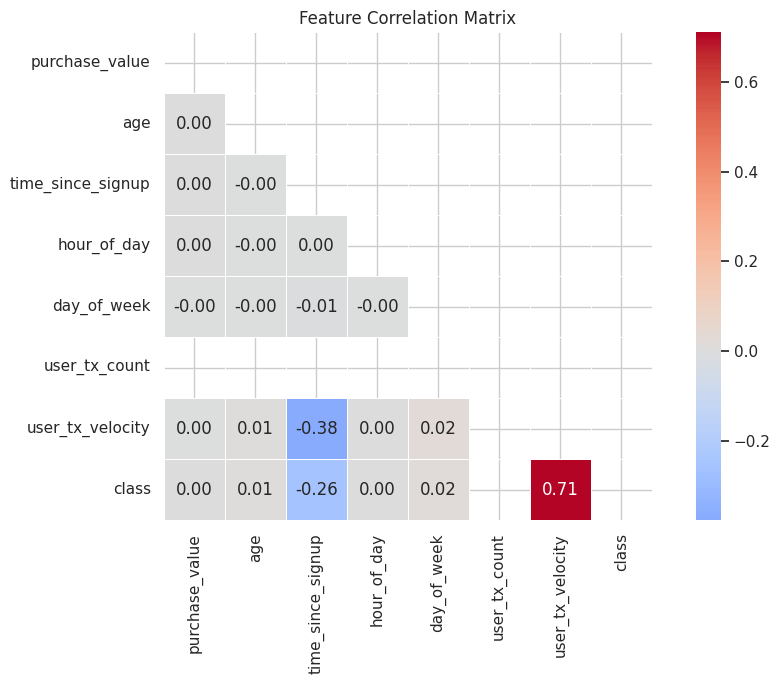

Correlation with class (fraud):
user_tx_velocity     0.7114
day_of_week          0.0189
age                  0.0066
hour_of_day          0.0020
purchase_value       0.0010
time_since_signup   -0.2579
user_tx_count           NaN
Name: class, dtype: float64


In [6]:
num_cols = ["purchase_value","age","time_since_signup","hour_of_day",
            "day_of_week","user_tx_count","user_tx_velocity","class"]
corr = fraud[num_cols].corr()
plt.figure(figsize=(10,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.savefig(PROC+"fe_correlation.png", bbox_inches="tight")
plt.show()
print("Correlation with class (fraud):")
print(corr["class"].drop("class").sort_values(ascending=False).round(4))